In [36]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [37]:
df = pd.read_csv("smartcart_customers.csv")

In [ ]:
df.shape
df.isnull().sum()

## Data preprocessing

## 1. Handle Missing Value

In [39]:
df["Income"] =df["Income"].fillna(df["Income"].median())

In [ ]:
df.isnull().sum()

## Feature Engineering

In [ ]:
df.columns

In [42]:
#AGE
df["Age"] = 2026-df["Year_Birth"]

In [43]:
#Customer Joinning Dates
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [45]:
#spending
df["Total_spending"] = df["Customer_Tenure_Days"]+ df["MntFruits"]+ df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [46]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [47]:
# Education
df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate", "PhD": "Postgraduate"
})

In [48]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [49]:
#Marital Status
df["Living_With"] =  df["Marital_Status"].replace({
    "Married": "Partner", "Together ": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})


In [50]:
df["Living_With"].value_counts()

Living_With
Partner     864
Alone       796
Together    580
Name: count, dtype: int64

In [ ]:
df.head()

## Drop Columns

In [52]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome" , "Teenhome","Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns = cols_to_drop)

In [ ]:
df_cleaned.shape
df_cleaned.head()

## Outliers

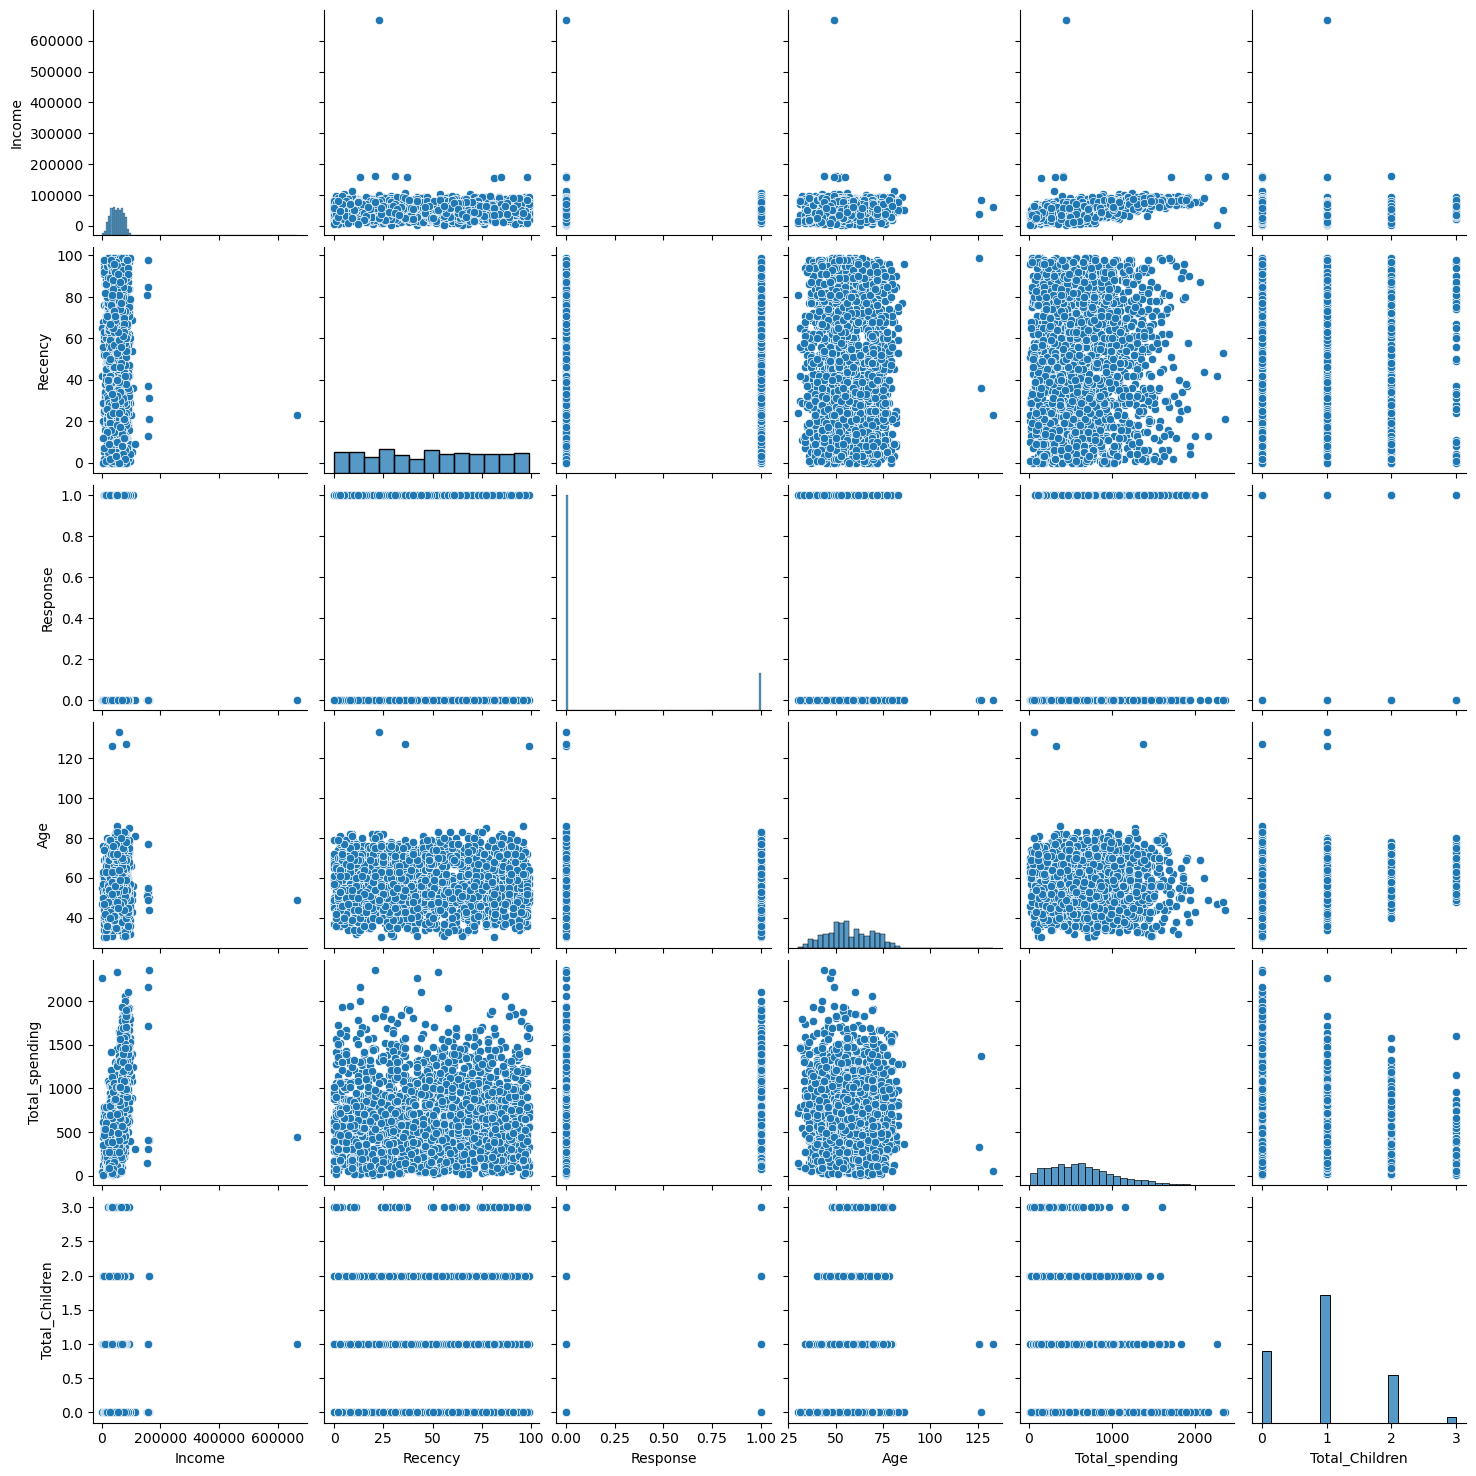

In [54]:
cols = ["Income", "Recency", "Response", "Age", "Total_spending", "Total_Children"]

#relative plots of some feature - pair plots
sns.pairplot(df_cleaned[cols])

In [55]:
# remove Outliers

print("data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] <600_00 ) ]

print("data size without outliers:", len(df_cleaned))

data size with outliers: 2240
data size without outliers: 1397


## Heatmap

In [56]:
corr = df_cleaned.corr(numeric_only  = True)

<Axes: >

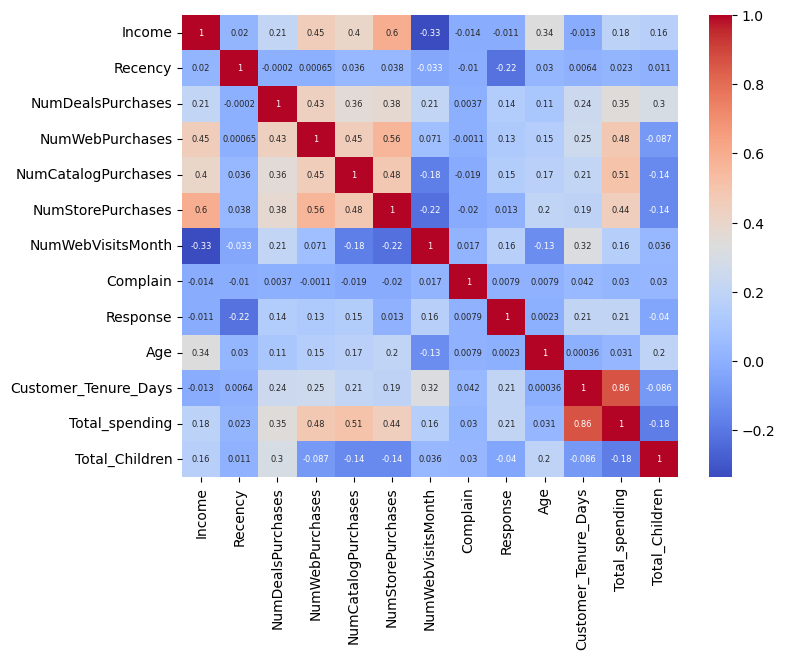

In [57]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm"   
)

# Encoding


In [58]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [ ]:
enc_df.head()

In [60]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis = 1)

In [ ]:
df_encoded.shape
df_encoded.head()

# Scaling

In [70]:
from sklearn.preprocessing import StandardScaler

X = df_encoded

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [ ]:
X_scaled

# Visualize

In [72]:
X_scaled.shape

(1397, 19)

In [87]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

In [88]:
pca.explained_variance_ratio_

array([0.18341927, 0.11552285, 0.09123858])

Text(0.5, 0.92, '3D Projection')

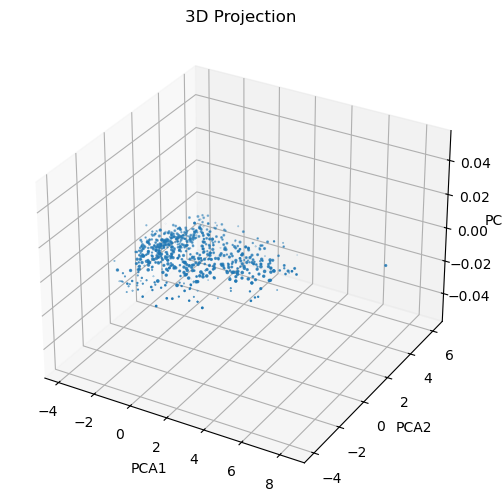

In [99]:
# plot
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

plt.scatter(X_pca[:, 0],  X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Projection")

In [96]:
pca.explained_variance_ratio_

array([0.18341927, 0.11552285, 0.09123858])

## analyze K Value

# 1. Elbow Method

In [100]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)
    


In [101]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [102]:
print("best k =", optimal_k)

best k = 4


Text(0, 0.5, 'WCSS')

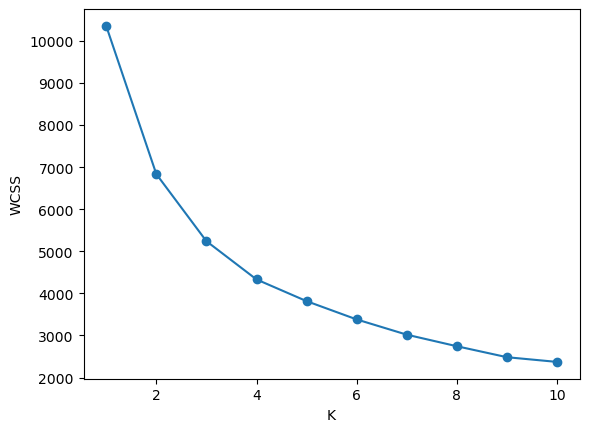

In [103]:
# plot

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

## 2. Silhouette Score

Text(0, 0.5, 'Silhouette score')

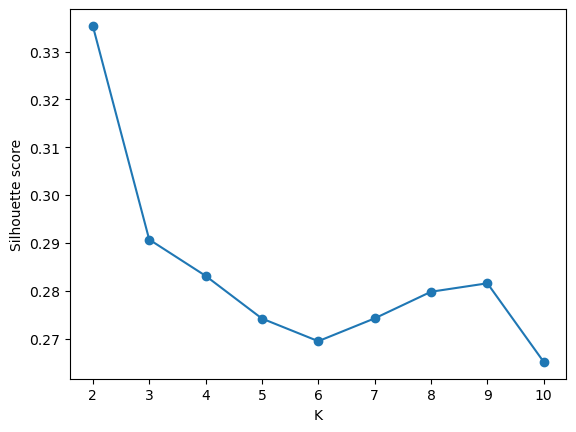

In [104]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# plot
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'SS')

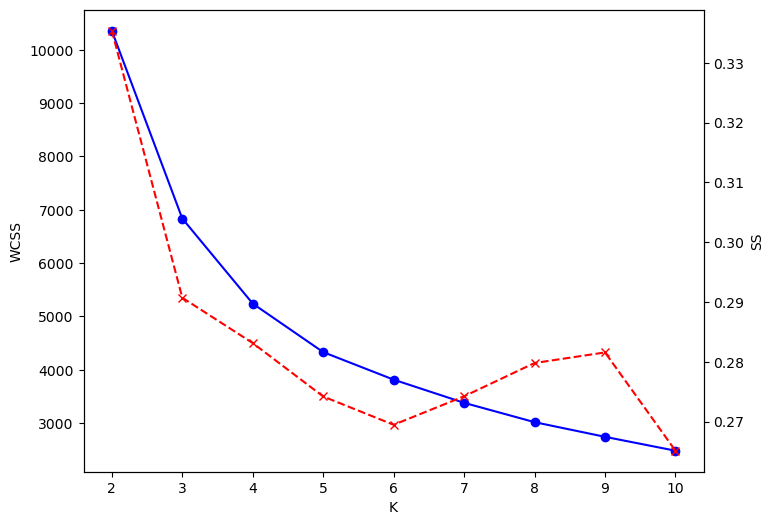

In [105]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

## clustering

In [106]:
# K_means

kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

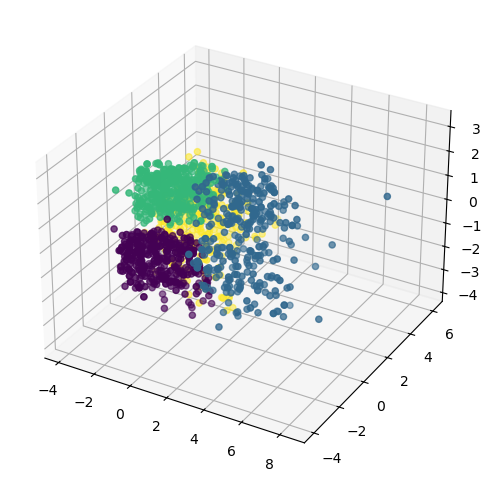

In [107]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

In [109]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

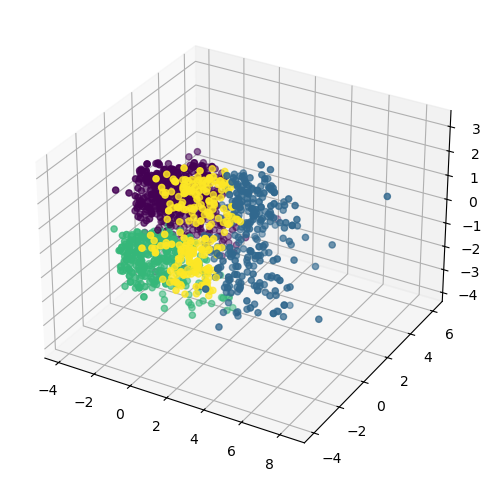

In [110]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

## Characterization of Clusters

In [111]:
X["cluster"] = labels_agg

In [ ]:
X.head()

<Axes: xlabel='cluster', ylabel='count'>

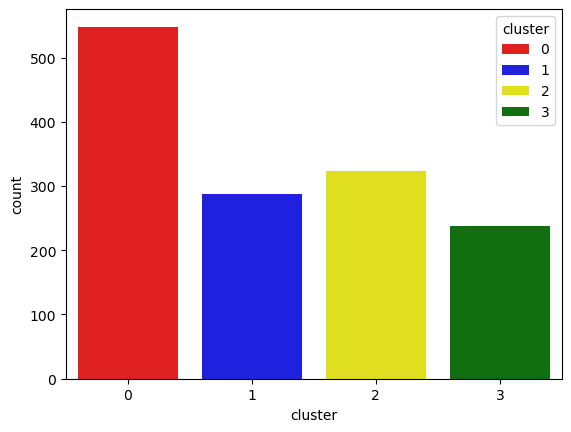

In [115]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_spending', ylabel='Income'>

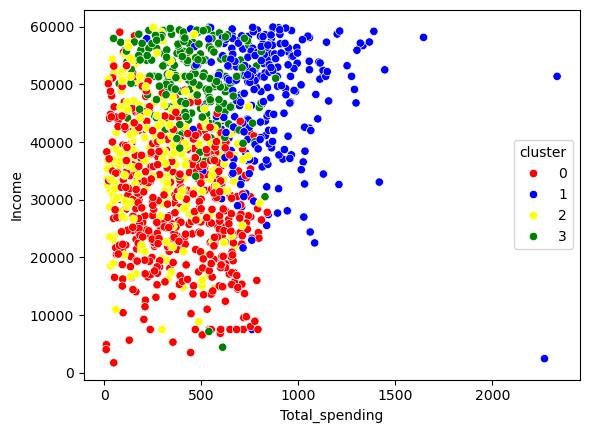

In [117]:
# Income & Spending patterns

sns.scatterplot(x=X["Total_spending"], y=X["Income"], hue=X["cluster"], palette=pal)

In [118]:
# Cluster Summary
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        29557.116788  50.136861           1.826642         1.773723   
1        47669.336237  50.599303           4.484321         6.240418   
2        37206.453704  44.978395           1.898148         1.944444   
3        49984.098739  51.004202           3.046218         4.689076   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.352190           2.901460           6.804745  0.016423   
1                   2.996516           6.871080           6.881533  0.013937   
2                   0.487654           3.086420           6.151235  0.006173   
3                   1.894958           5.819328           5.365546  0.000000   

         Response        Age  Customer_Tenure_Days  Total_spending  \
cluster         